In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

In [56]:
df = pd.read_csv('preprocessed.csv')
df.info()

/tmp/ipykernel_33878/207180881.py:1: DtypeWarning: Columns (0: CANCELLATION_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('preprocessed.csv')


<class 'pandas.DataFrame'>
RangeIndex: 1551842 entries, 0 to 1551841
Data columns (total 32 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   FL_DATE                  1551842 non-null  str    
 1   AIRLINE                  1551842 non-null  str    
 2   AIRLINE_DOT              1551842 non-null  str    
 3   AIRLINE_CODE             1551842 non-null  str    
 4   DOT_CODE                 1551842 non-null  int64  
 5   FL_NUMBER                1551842 non-null  int64  
 6   ORIGIN                   1551842 non-null  str    
 7   ORIGIN_CITY              1551842 non-null  str    
 8   DEST                     1551842 non-null  str    
 9   DEST_CITY                1551842 non-null  str    
 10  CRS_DEP_TIME             1551842 non-null  int64  
 11  DEP_TIME                 791105 non-null   float64
 12  DEP_DELAY                790821 non-null   float64
 13  TAXI_OUT                 779254 non-null   float64
 1

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
DOT_CODE,1551842.0,19973.025011,390.584617,19393.0,19790.0,19977.0,20378.0,20452.0
FL_NUMBER,1551842.0,2567.299987,1767.008400,1.0,1081.0,2207.0,3913.0,8819.0
CRS_DEP_TIME,1551842.0,1344.878370,492.629947,1.0,920.0,1340.0,1749.0,2359.0
DEP_TIME,791105.0,1331.814452,500.209360,1.0,918.0,1325.0,1740.0,2400.0
DEP_DELAY,790821.0,11.158143,52.397960,-84.0,-6.0,-2.0,7.0,2368.0
TAXI_OUT,779254.0,16.662516,9.218929,1.0,11.0,14.0,19.0,186.0
WHEELS_OFF,779254.0,1351.797156,501.143026,1.0,931.0,1335.0,1752.0,2400.0
WHEELS_ON,775721.0,1461.729514,526.844476,1.0,1049.0,1500.0,1907.0,2400.0
TAXI_IN,775721.0,7.665515,6.250633,1.0,4.0,6.0,9.0,214.0
CRS_ARR_TIME,1551842.0,1501.680946,522.297369,1.0,1108.0,1532.0,1933.0,2400.0


In [58]:
df['CANCELLED'].value_counts()

CANCELLED
1.0    775921
0.0    775921
Name: count, dtype: int64

In [74]:
df['DIVERTED'].value_counts()

DIVERTED
0.0    1550062
1.0       1780
Name: count, dtype: int64

ValueError: 'c' argument has 2 elements, which is inconsistent with 'x' and 'y' with size 1551842.

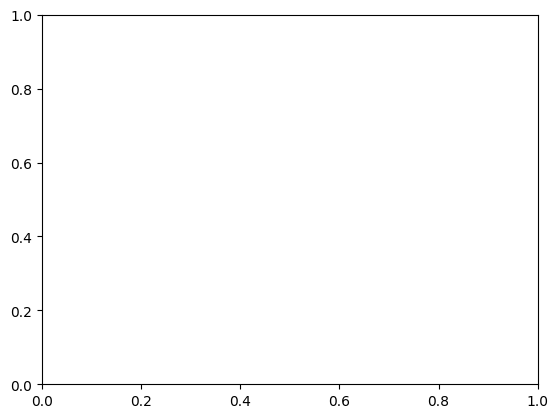

In [ ]:
sns.scatterplot(x='', y='DIVERTED', data=df, color=['blue', 'orange'])

In [59]:
df['ARR_DELAY'].describe()

count    774141.000000
mean          4.280709
std          51.493680
min         -89.000000
25%         -16.000000
50%          -7.000000
75%           7.000000
max        2221.000000
Name: ARR_DELAY, dtype: float64

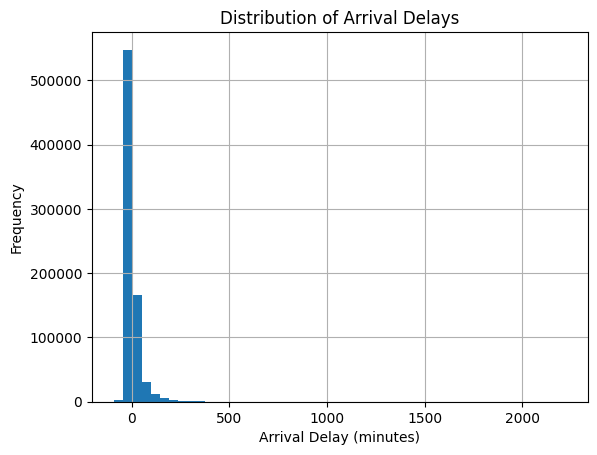

In [60]:
df['ARR_DELAY'].hist(bins=50)
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delays')
plt.show()

Há uma quantia pequena de valores sobressalentes.

In [61]:
Q1 = df['ARR_DELAY'].quantile(0.25)
Q3 = df['ARR_DELAY'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

IQR

np.float64(23.0)

<Axes: xlabel='ARR_DELAY', ylabel='CANCELLED'>

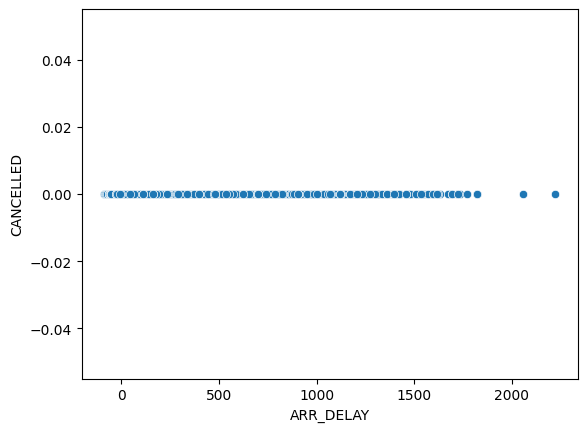

In [62]:
sns.scatterplot(x='ARR_DELAY', y='CANCELLED', data=df)

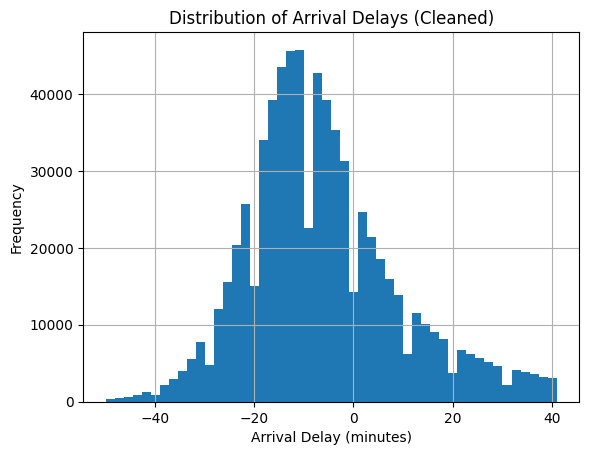

In [63]:
df_cleaned = df[(df['ARR_DELAY'] >= lower_bound) & (df['ARR_DELAY'] <= upper_bound)]
df_cleaned['ARR_DELAY'].hist(bins=50)
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delays (Cleaned)')
plt.show()

Cortou a ponta direita.

In [64]:
# z_scores = (df['ARR_DELAY'] - df['ARR_DELAY'].mean()) / df['ARR_DELAY'].std()
# df_cleaned = df[(z_scores >= -3) & (z_scores <= 3)]

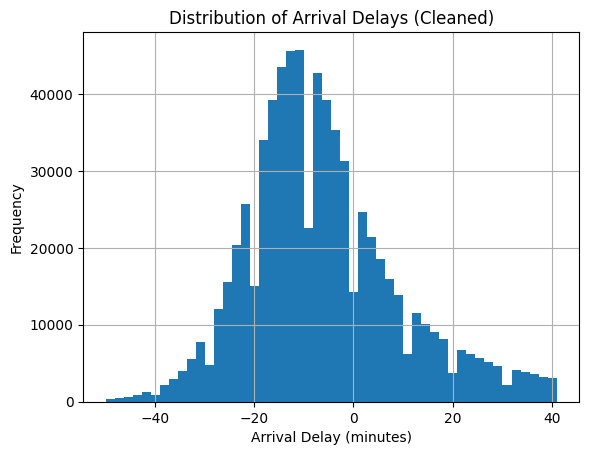

In [65]:
df_cleaned['ARR_DELAY'].hist(bins=50)
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delays (Cleaned)')
plt.show()

In [66]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [71]:
to_drop = df_cleaned.select_dtypes(include=['object']).columns
print("Dropping columns:", to_drop)
df_cleaned = df_cleaned.drop(columns=to_drop)
df_cleaned = df_cleaned.drop(columns=['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT'])
# df_cleaned['ORIGIN'] = le.fit_transform(df_cleaned['ORIGIN'])
# df_cleaned['DEST'] = le.fit_transform(df_cleaned['DEST'])
# df_cleaned['AIRLINE'] = le.fit_transform(df_cleaned['AIRLINE']
# df_cleaned.dropna(inplace=True)
df_cleaned.info()

Dropping columns: Index([], dtype='str')
<class 'pandas.DataFrame'>
Index: 705675 entries, 775921 to 1551840
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DOT_CODE          705675 non-null  int64  
 1   FL_NUMBER         705675 non-null  int64  
 2   CRS_DEP_TIME      705675 non-null  int64  
 3   DEP_TIME          705675 non-null  float64
 4   DEP_DELAY         705675 non-null  float64
 5   TAXI_OUT          705675 non-null  float64
 6   WHEELS_OFF        705675 non-null  float64
 7   WHEELS_ON         705675 non-null  float64
 8   TAXI_IN           705675 non-null  float64
 9   CRS_ARR_TIME      705675 non-null  int64  
 10  ARR_TIME          705675 non-null  float64
 11  ARR_DELAY         705675 non-null  float64
 12  CANCELLED         705675 non-null  float64
 13  DIVERTED          705675 non-null  float64
 14  CRS_ELAPSED_TIME  705675 non-null  float64
 15  ELAPSED_TIME      705675 non-null  fl

In [72]:
df_cleaned['CANCELLED'].value_counts()

CANCELLED
0.0    705675
Name: count, dtype: int64

<Axes: >

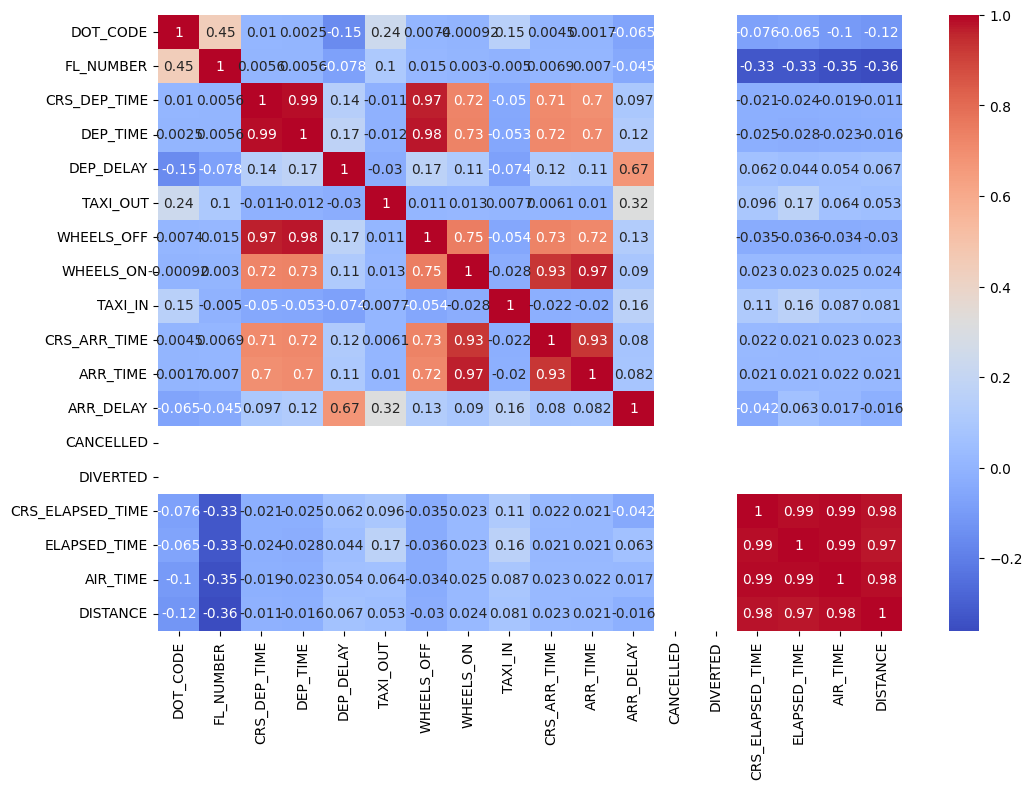

In [81]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm')

In [70]:
clf = sklearn.linear_model.LogisticRegression()
X = df_cleaned.drop(columns=['CANCELLED'])
y = df_cleaned['CANCELLED']
clf.fit(X, y)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values